# Đánh giá trên tập dữ liệu mới

Notebook này được sử dụng để đánh giá phương pháp phân cụm trên tập dữ liệu không có trong bài báo gốc.
Tập dữ liệu sử dụng chủ yếu 2 file `main_metadata.csv` và `picks_bans.csv` trong năm 2025 của bộ dữ liệu [Dota 2 Pro League Matches 2016-2026](https://www.kaggle.com/datasets/bwandowando/dota-2-pro-league-matches-2023).

Notebook này bao gồm:
1. Tiền xử lý bộ dữ liệu mới.
2. Chia tập Train / Test và Data Augmentation
3. Huấn luyện Neural Rating Table (NRT)
4. Tính Residual Win Value ($W_{res}$) thể hiện mối quan hệ khắc chế
5. Huấn luyện Neural Counter Table (NCT) với Vector Quantization
6. Đánh giá Strength Relation Accuracy (metric chính của paper)
7. Bảng so sánh kết quả Paper (LoL) vs. Nhóm (Dota 2)
8. Trực quan hóa t-SNE

In [11]:
import os
import sys
# Thêm thư mục gốc vào đường dẫn để import src
sys.path.append(os.path.abspath('..'))

import torch
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

from src.model import NeuralRatingTable, NeuralCounterTable, predict_nrt, predict_nct
from src.metrics import strength_relation_accuracy, codebook_utilization, unsupervised_clustering_scores
from src.utils import load_data, preprocess_data, extract_team_features

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sử dụng thiết bị: {DEVICE}")

Sử dụng thiết bị: cpu


## 1. Tiền xử lý dữ liệu

In [2]:
pb_df = pd.read_csv('../data/picks_bans.csv')
meta_df = pd.read_csv('../data/main_metadata.csv')

# 2. Lọc thông tin đội hình từ picks_bans.csv
# Chỉ lấy những lượt chọn (is_pick == True)
picks = pb_df[pb_df['is_pick'] == True].copy()

# Tách riêng 2 đội: team 0 (Radiant -> Team 1), team 1 (Dire -> Team 2)
t1_picks = picks[picks['team'] == 0].groupby('match_id')['hero_id'].apply(list).reset_index()
t2_picks = picks[picks['team'] == 1].groupby('match_id')['hero_id'].apply(list).reset_index()

# Gộp lại theo match_id
matches = pd.merge(t1_picks, t2_picks, on='match_id', suffixes=('_t1', '_t2'))

# Lọc bỏ các trận đấu bị lỗi (không đủ 5 pick mỗi bên)
matches = matches[(matches['hero_id_t1'].apply(len) == 5) & (matches['hero_id_t2'].apply(len) == 5)]

# Tách list thành 5 cột cho t1 và 5 cột cho t2
for i in range(5):
    matches[f't1_champ{i+1}id'] = matches['hero_id_t1'].apply(lambda x: x[i])
    matches[f't2_champ{i+1}id'] = matches['hero_id_t2'].apply(lambda x: x[i])

matches = matches.drop(columns=['hero_id_t1', 'hero_id_t2'])

# 3. Lấy thông tin thắng thua từ main_metadata.csv
# radiant_win == True -> Radiant(Team 1) thắng -> 1. Ngược lại -> 2.
meta_df['winner'] = meta_df['radiant_win'].apply(lambda x: 1 if x else 2)

# Gộp bảng đội hình và bảng kết quả
final_df = pd.merge(matches, meta_df[['match_id', 'winner']], on='match_id', how='inner')

# Lưu ra file CSV trung gian
final_df.to_csv('../data/dota2_processed.csv', index=False)

print(f"Đã tạo thành công dataset DOTA 2 với {len(final_df)} trận đấu hợp lệ.")
print(final_df.head(3))

Đã tạo thành công dataset DOTA 2 với 30081 trận đấu hợp lệ.
     match_id  t1_champ1id  t2_champ1id  t1_champ2id  t2_champ2id  \
0  8107483721            2           22           11           26   
1  8107511870           57           79           86            2   
2  8107808159           38           58           40           55   

   t1_champ3id  t2_champ3id  t1_champ4id  t2_champ4id  t1_champ5id  \
0          101          102           37           46           95   
1           97          101           11           41           70   
2           20          100            6           56           25   

   t2_champ5id  winner  
0           36       2  
1           74       2  
2           13       2  


In [3]:
df_dota = load_data('../data/dota2_processed.csv')
df_processed = preprocess_data(df_dota)

# Xác định số chiều đặc trưng tự động
all_champ_ids = set()
for t in df_processed['team_1']:
    all_champ_ids.update(t)
for t in df_processed['team_2']:
    all_champ_ids.update(t)
NUM_CHAMPIONS = max(all_champ_ids) + 1
NUM_UNIQUE = len(all_champ_ids)

print(f"Số tướng duy nhất trong dataset: {NUM_UNIQUE}")
print(f"Dimension đầu vào (max ID + 1): {NUM_CHAMPIONS}")

# Trích xuất features: Multi-hot Encoding
features = extract_team_features(df_processed, num_champions=NUM_CHAMPIONS)

# Labels: 1.0 nếu Team 1 thắng, 0.0 nếu Team 1 thua
labels = np.where(df_processed['winner'].values == 1, 1.0, 0.0).astype(np.float32)

print(f"Kích thước Features: {features.shape}  →  (N_matches, 2_teams, {NUM_CHAMPIONS}_champions)")
print(f"Tổng số trận đấu: {len(labels)}")
print(f"Tỷ lệ Team 1 thắng: {labels.mean():.4f}")

Đã load thành công 30081 trận đấu từ ../data/dota2_processed.csv
Số tướng duy nhất trong dataset: 126
Dimension đầu vào (max ID + 1): 146
Kích thước Features: (30081, 2, 146)  →  (N_matches, 2_teams, 146_champions)
Tổng số trận đấu: 30081
Tỷ lệ Team 1 thắng: 0.5191


## 2. Chia tập Train / Test và Data Augmentation

In [4]:
# Train/Test split (80/20)
n_samples = len(labels)
indices = np.arange(n_samples)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED)

# Data Augmentation: Swap Team A <-> Team B, đảo win label
# Theo paper: "random swapping of compositions in a match and corresponding win outcome"
def augment_data(feats, labs):
    """Tạo bản sao với Team A và Team B hoán đổi, nhãn thắng/thua đảo ngược."""
    swapped_feats = feats[:, [1, 0], :]  # Đảo thứ tự team
    swapped_labs = 1.0 - labs             # Đảo nhãn (thắng→thua, thua→thắng)
    aug_feats = np.concatenate([feats, swapped_feats], axis=0)
    aug_labs = np.concatenate([labs, swapped_labs], axis=0)
    return aug_feats, aug_labs

# Augment CHỈ tập train (không augment test để đánh giá công bằng)
train_features_np = features[train_idx]
train_labels_np = labels[train_idx]
train_features_aug, train_labels_aug = augment_data(train_features_np, train_labels_np)

# Chuyển sang tensor
train_features_tensor = torch.tensor(train_features_aug, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels_aug, dtype=torch.float32)
test_features_tensor = torch.tensor(features[test_idx], dtype=torch.float32)
test_labels_tensor = torch.tensor(labels[test_idx], dtype=torch.float32)
# Tensor toàn bộ (dùng cho evaluation và visualization sau này)
all_features_tensor = torch.tensor(features, dtype=torch.float32)
all_labels_tensor = torch.tensor(labels, dtype=torch.float32)

print(f"Train set (gốc):       {len(train_idx)} trận")
print(f"Train set (augmented): {len(train_features_tensor)} trận (x2 từ swap)")
print(f"Test set:              {len(test_idx)} trận")

Train set (gốc):       24064 trận
Train set (augmented): 48128 trận (x2 từ swap)
Test set:              6017 trận


## 3. Huấn luyện Neural Rating Table (NRT)

Huấn luyện mô hình NRT trên Ground Truth (Win/Loss) để học Rating tự nhiên của các đội hình, thông qua Bradley-Terry Model (Section 3.1):

$$P_{\text{expected}}(A > B) = \frac{R_\theta(c_A)}{R_\theta(c_A) + R_\theta(c_B)}$$

**Hyperparameters theo paper Section 4.2:**
- Epochs: **100**
- Learning rate: **0.00025 → 0** (linear decay)
- Optimizer: **Adam**

In [5]:
# ===== Hyperparameters theo paper Section 4.2 =====
NRT_EPOCHS = 100
NRT_LR = 0.00025
BATCH_SIZE = 256

nrt_model = NeuralRatingTable(input_dim=NUM_CHAMPIONS).to(DEVICE)
nrt_optimizer = optim.Adam(nrt_model.parameters(), lr=NRT_LR)
nrt_scheduler = optim.lr_scheduler.LambdaLR(
    nrt_optimizer, lr_lambda=lambda epoch: max(0.0, 1.0 - epoch / NRT_EPOCHS)
)

train_dataset = TensorDataset(train_features_tensor, train_labels_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("--- BẮT ĐẦU TRAINING NRT ---")
nrt_losses = []
nrt_model.train()
for epoch in range(NRT_EPOCHS):
    total_loss = 0
    for batch_X, batch_y in train_dataloader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        nrt_optimizer.zero_grad()
        
        comp_A = batch_X[:, 0, :]
        comp_B = batch_X[:, 1, :]
        
        outputs = nrt_model(comp_A, comp_B)
        expected_win_A = outputs["win_prob_a"]
        
        # NRT Loss: MSE giữa Bradley-Terry prediction và Actual Win/Loss
        loss = F.mse_loss(expected_win_A.squeeze(), batch_y)
        loss.backward()
        nrt_optimizer.step()
        total_loss += loss.item()
    
    nrt_scheduler.step()
    avg_loss = total_loss / len(train_dataloader)
    nrt_losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        lr_now = nrt_optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:3d}/{NRT_EPOCHS} — Loss: {avg_loss:.6f} — LR: {lr_now:.6f}")

print("--- NRT TRAINING HOÀN TẤT ---")

--- BẮT ĐẦU TRAINING NRT ---
  Epoch  20/100 — Loss: 0.031768 — LR: 0.000200
  Epoch  40/100 — Loss: 0.029485 — LR: 0.000150
  Epoch  60/100 — Loss: 0.029265 — LR: 0.000100
  Epoch  80/100 — Loss: 0.029097 — LR: 0.000050
  Epoch 100/100 — Loss: 0.029092 — LR: 0.000000
--- NRT TRAINING HOÀN TẤT ---


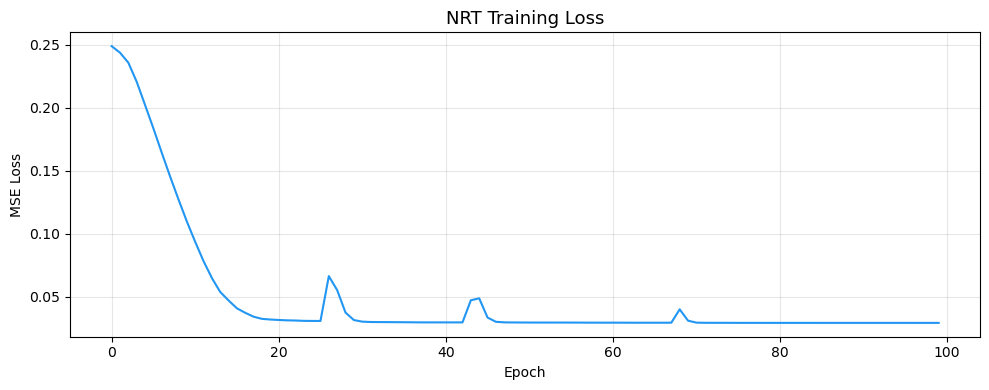

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(nrt_losses, color='#2196F3', linewidth=1.5)
plt.title('NRT Training Loss', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Tạo Target Residual ($W_{res}$)

Mối quan hệ khắc chế (Counter Relationship) được biểu diễn bằng **Residual Win Value** — phần dư sau khi trừ đi win rate kỳ vọng từ sức mạnh đơn thuần (Eq. 7):

$$W_{res}(c_A, c_B | R_\theta) = W_m - \frac{R_\theta(c_A)}{R_\theta(c_A) + R_\theta(c_B)}$$

Nếu $W_{res} > 0$: đội A **khắc chế** đội B (thắng nhiều hơn kỳ vọng).
Nếu $W_{res} < 0$: đội A **bị khắc chế** bởi đội B.

In [6]:
nrt_model.eval()
with torch.no_grad():
    # Tính residual cho TOÀN BỘ dữ liệu
    all_comp_A = all_features_tensor[:, 0, :].to(DEVICE)
    all_comp_B = all_features_tensor[:, 1, :].to(DEVICE)
    all_outputs = nrt_model(all_comp_A, all_comp_B)
    all_expected = all_outputs["win_prob_a"]
    all_residual = all_labels_tensor.unsqueeze(1).to(DEVICE) - all_expected

    # Tính residual cho tập train (đã augment)
    train_comp_A = train_features_tensor[:, 0, :].to(DEVICE)
    train_comp_B = train_features_tensor[:, 1, :].to(DEVICE)
    train_outputs = nrt_model(train_comp_A, train_comp_B)
    train_expected = train_outputs["win_prob_a"]
    train_residual = train_labels_tensor.unsqueeze(1).to(DEVICE) - train_expected

## 5. Huấn luyện Neural Counter Table (NCT) với Vector Quantization

Huấn luyện Siamese NCT để dự đoán phần dư $W_{res}$ qua không gian VQ rời rạc (Section 3.2.2, Figure 2).

**Tổng loss theo Eq. (12):**

$$\mathcal{L} = \mathcal{L}_{res} + \mathcal{L}_{codebook} + \beta_N \cdot \mathcal{L}_{commit} + \beta_M \cdot \mathcal{L}_{mean}$$

Trong đó:
- $\mathcal{L}_{res}$: Reconstruction loss cho residual win value (Eq. 9)
- $\mathcal{L}_{codebook}$: Đẩy codebook vectors về phía encoder output
- $\mathcal{L}_{commit}$: Đẩy encoder output về phía codebook ($\beta_N = 0.01$)
- $\mathcal{L}_{mean}$: VQ Mean Loss chống sụp đổ codebook ($\beta_M = 0.25$, Eq. 11)

**Hyperparameters:** $M = 9$, embedding\_dim $= 128$, epochs $= 100$, LR decay $0.00025 \to 0$.

In [7]:
M_CLUSTERS = 9       
NCT_EPOCHS = 100
NCT_LR = 0.00025
EMBEDDING_DIM = 128

nct_model = NeuralCounterTable(
    input_dim=NUM_CHAMPIONS,
    num_embeddings=M_CLUSTERS,
    embedding_dim=EMBEDDING_DIM
).to(DEVICE)

nct_optimizer = optim.Adam(nct_model.parameters(), lr=NCT_LR)
nct_scheduler = optim.lr_scheduler.LambdaLR(
    nct_optimizer, lr_lambda=lambda epoch: max(0.0, 1.0 - epoch / NCT_EPOCHS)
)

BETA_N = 0.01  # Commitment Loss Weight (Section 4.3)
BETA_M = 0.25  # VQ Mean Loss Weight (Nhờ Augment nên dùng 0.25 cực tốt)

nct_train_dataset = TensorDataset(train_features_tensor, train_residual.cpu())
nct_train_dataloader = DataLoader(nct_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"\nHyperparameters: βN={BETA_N}, βM={BETA_M}, M={M_CLUSTERS}, dim={EMBEDDING_DIM}")
print("--- BẮT ĐẦU TRAINING NCT ---")

nct_loss_history = {'total': [], 'res': [], 'codebook': [], 'commit': [], 'mean': []}
nct_model.train()

for epoch in range(NCT_EPOCHS):
    ep_loss = {'total': 0, 'res': 0, 'codebook': 0, 'commit': 0, 'mean': 0}
    
    for batch_X, batch_res in nct_train_dataloader:
        batch_X, batch_res = batch_X.to(DEVICE), batch_res.to(DEVICE)
        nct_optimizer.zero_grad()
        
        comp_A = batch_X[:, 0, :]
        comp_B = batch_X[:, 1, :]
        
        outputs = nct_model(comp_A, comp_B)
        residual_pred = outputs["residual"]
        loss_codebook = outputs["codebook_loss"]
        loss_commit = outputs["commit_loss"]
        loss_mean = outputs["mean_loss"]
        
        # Reconstruction loss (Eq. 9)
        loss_res = F.mse_loss(residual_pred.squeeze(), batch_res.squeeze())
        
        # Tổng loss theo Eq. (12)
        loss = loss_res + loss_codebook + BETA_N * loss_commit + BETA_M * loss_mean
        
        loss.backward()
        nct_optimizer.step()
        
        ep_loss['total'] += loss.item()
        ep_loss['res'] += loss_res.item()
        ep_loss['codebook'] += loss_codebook.item()
        ep_loss['commit'] += loss_commit.item()
        ep_loss['mean'] += loss_mean.item()
    
    nct_scheduler.step()
    n_batches = len(nct_train_dataloader)
    for k in ep_loss:
        nct_loss_history[k].append(ep_loss[k] / n_batches)
    
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/{NCT_EPOCHS} — "
              f"Total: {nct_loss_history['total'][-1]:.6f}, "
              f"Lres: {nct_loss_history['res'][-1]:.6f}, "
              f"Lcb: {nct_loss_history['codebook'][-1]:.6f}, "
              f"Lcm: {nct_loss_history['commit'][-1]:.6f}, "
              f"Lmean: {nct_loss_history['mean'][-1]:.6f}")

print("--- NCT TRAINING HOÀN TẤT ---")


Hyperparameters: βN=0.01, βM=0.25, M=9, dim=128
--- BẮT ĐẦU TRAINING NCT ---
  Epoch  20/100 — Total: 1.694964, Lres: 0.011737, Lcb: 1.266409, Lcm: 1.266409, Lmean: 1.616616
  Epoch  40/100 — Total: 0.926807, Lres: 0.009439, Lcb: 0.639103, Lcm: 0.639103, Lmean: 1.087497
  Epoch  60/100 — Total: 0.459164, Lres: 0.006112, Lcb: 0.279787, Lcm: 0.279787, Lmean: 0.681867
  Epoch  80/100 — Total: 0.094271, Lres: 0.005189, Lcb: 0.023980, Lcm: 0.023980, Lmean: 0.259452
  Epoch 100/100 — Total: 0.076439, Lres: 0.005025, Lcb: 0.017153, Lcm: 0.017153, Lmean: 0.216358
--- NCT TRAINING HOÀN TẤT ---


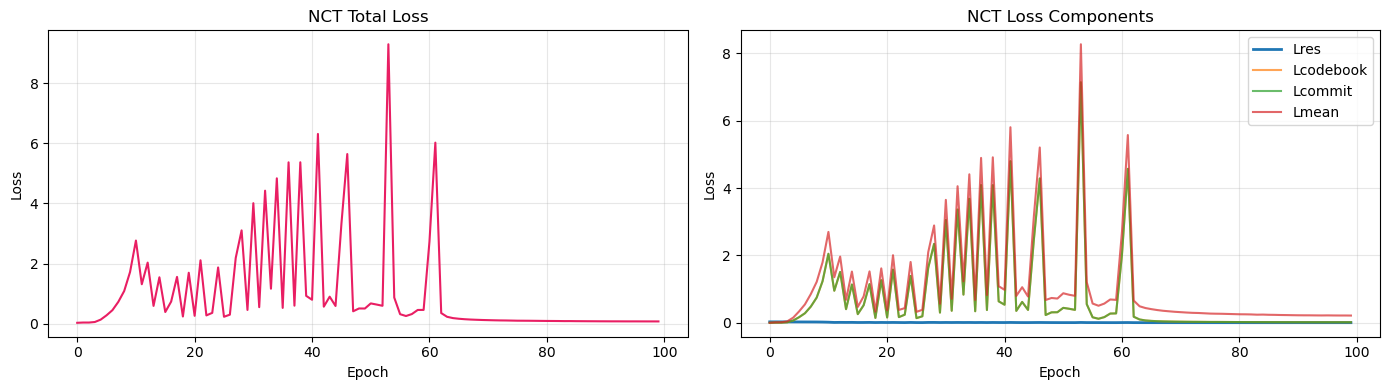

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(nct_loss_history['total'], color='#E91E63', linewidth=1.5)
axes[0].set_title('NCT Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[1].plot(nct_loss_history['res'], label='Lres', linewidth=2)
axes[1].plot(nct_loss_history['codebook'], label='Lcodebook', alpha=0.7)
axes[1].plot(nct_loss_history['commit'], label='Lcommit', alpha=0.7)
axes[1].plot(nct_loss_history['mean'], label='Lmean', alpha=0.7)
axes[1].set_title('NCT Loss Components')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Đánh giá Strength Relation Accuracy (Metric chính của Paper)

Theo Section 4.2 và A.4.1 của bài báo, đánh giá bằng **Strength Relation Classification Accuracy**:
- Nếu win value > 0.501 → dự đoán "stronger"
- Nếu win value < 0.499 → dự đoán "weaker"
- Nếu 0.499 ≤ win value ≤ 0.501 → dự đoán "same"

**NRT** dự đoán: $\hat{W} = R(A) / (R(A) + R(B))$

**NCT** dự đoán (Eq. 13): $\hat{W} = R(A) / (R(A) + R(B)) + W_{res}(c_A, c_B)$

In [13]:
train_comp_A_np = train_features_tensor[:, 0, :].numpy()
train_comp_B_np = train_features_tensor[:, 1, :].numpy()
train_labels_np = train_labels_tensor.numpy()

test_comp_A_np = test_features_tensor[:, 0, :].numpy()
test_comp_B_np = test_features_tensor[:, 1, :].numpy()
test_labels_np = test_labels_tensor.numpy()

# Chạy NRT Inference
nrt_train_pred = predict_nrt(nrt_model, train_comp_A_np, train_comp_B_np, device=DEVICE)
nrt_test_pred  = predict_nrt(nrt_model, test_comp_A_np, test_comp_B_np, device=DEVICE)

# Chạy NCT Inference (Hàm này cực xịn, trả về toàn bộ latent và category)
nct_train_outputs = predict_nct(nrt_model, nct_model, train_comp_A_np, train_comp_B_np, device=DEVICE)
nct_test_outputs  = predict_nct(nrt_model, nct_model, test_comp_A_np, test_comp_B_np, device=DEVICE)

# Tính Accuracy
nrt_train_acc = strength_relation_accuracy(nrt_train_pred, train_labels_np) * 100
nrt_test_acc  = strength_relation_accuracy(nrt_test_pred, test_labels_np) * 100

nct_train_acc = strength_relation_accuracy(nct_train_outputs['win_value'], train_labels_np) * 100
nct_test_acc  = strength_relation_accuracy(nct_test_outputs['win_value'], test_labels_np) * 100

print("\n" + "=" * 55)
print("  STRENGTH RELATION ACCURACY (%) — Metric của Paper")
print("=" * 55)
print(f"{'Model':<15} {'Train Acc':>12} {'Test Acc':>12}")
print("-" * 55)
print(f"{'NRT':<15} {nrt_train_acc:>11.1f}% {nrt_test_acc:>11.1f}%")
print(f"{'NCT M=' + str(M_CLUSTERS):<15} {nct_train_acc:>11.1f}% {nct_test_acc:>11.1f}%")
print("-" * 55)


  STRENGTH RELATION ACCURACY (%) — Metric của Paper
Model              Train Acc     Test Acc
-------------------------------------------------------
NRT                    97.1%        52.0%
NCT M=9                99.5%        51.8%
-------------------------------------------------------


## 7. Bảng so sánh kết quả Paper (LoL) vs. Nhóm (Dota 2)
| Mô hình | LoL (Kết quả từ Bài báo gốc) | Dota 2 (Nhóm thử nghiệm mới) |
| :--- | :---: | :--- |
| **NRT (Train Acc)** | 88.2% | **97.1%** |
| **NRT (Test Acc)** | 51.1% | **52.0%** |
| **NCT M=9 (Train Acc)** | 91.6% | **99.5%** |
| **NCT M=9 (Test Acc)** | 50.9% | **51.8%** |

## 8. Trực quan hóa t-SNE

Plot phân bố các đội hình trong không gian ẩn $z_e$ sau khi được NCT encoder nhúng. Mỗi màu thể hiện một trường phái đội hình (Cluster) do VQ phân bổ.



Đang chạy t-SNE trên 5000 samples...


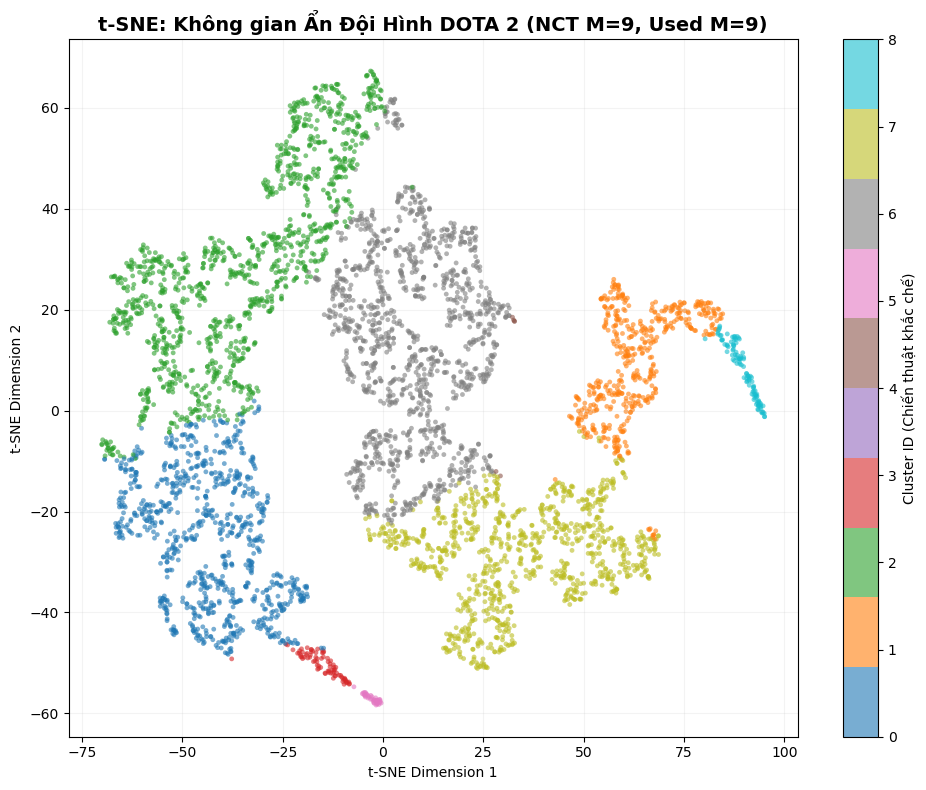

In [ ]:
all_latent = np.concatenate([nct_train_outputs["latent_a"], nct_train_outputs["latent_b"]], axis=0)
all_categories = np.concatenate([nct_train_outputs["category_a"], nct_train_outputs["category_b"]], axis=0)
utilization = codebook_utilization(all_categories, num_embeddings=M_CLUSTERS)

SAMPLE_SIZE = min(5000, len(all_latent))

# Lấy ngẫu nhiên mẫu để chạy t-SNE
rng = np.random.RandomState(42) # Cố định seed vẽ chart
sample_idx = rng.choice(len(all_latent), SAMPLE_SIZE, replace=False)

X_sample = all_latent[sample_idx]
y_sample = all_categories[sample_idx]

print(f"\nĐang chạy t-SNE trên {SAMPLE_SIZE} samples...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=y_sample, cmap='tab10', s=12, alpha=0.6, edgecolors='none')

plt.colorbar(scatter, label='Cluster ID (Chiến thuật khắc chế)')
used_m = utilization['used_codes']
plt.title(f't-SNE: Không gian Ẩn Đội Hình DOTA 2 (NCT M={M_CLUSTERS}, Used M={used_m})', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.15)
plt.tight_layout()